In [ ]:
import os
from pprint import pprint

import torch
from torch import nn  # nn contains all of PyTorch's building blocks for neural networks
import torch.optim as optim

import matplotlib.pyplot as plt

from torchviz import make_dot


# Check PyTorch version
print(f"{torch.__version__=}")

if os.path.abspath("..") not in os.sys.path:
    os.sys.path.append(os.path.abspath(".."))


torch.__version__='2.8.0+cu128'


In [3]:
import math

class Node:
    def __init__(self, value, parents=(), grad_fn=None):
        self.value = value
        self.parents = parents
        self.grad = 0.0
        self.grad_fn = grad_fn

    def backward(self, grad_output=1.0):
        self.grad += grad_output
        if self.grad_fn:
            self.grad_fn(self, grad_output)

# Define ops
def mul(a, b):
    def grad_fn(node, grad_output):
        a.backward(grad_output * b.value)
        b.backward(grad_output * a.value)
    return Node(a.value * b.value, (a, b), grad_fn)

def add(a, b):
    def grad_fn(node, grad_output):
        a.backward(grad_output)
        b.backward(grad_output)
    return Node(a.value + b.value, (a, b), grad_fn)

def sin(a):
    def grad_fn(node, grad_output):
        a.backward(grad_output * math.cos(a.value))
    return Node(math.sin(a.value), (a,), grad_fn)


In [ ]:
# Build graph manually
x = Node(2.0)
a = mul(x, x)
b = mul(Node(3.0), x)
c = add(a, b)
y = sin(c)

# Backprop
y.backward()
import torch
import torch.nn as nn
import torch.optim as optim
print("y:", y.value)
print("dy/dx:", x.grad)


y: -0.5440211108893698
dy/dx: -5.873500703535167


In [5]:
x = torch.tensor(2.0, requires_grad=True)
y = x ** 2 + 3 * x
z = torch.sin(y)

print(z.grad_fn)                 # e.g. <SinBackward0 object at ...>
print(z.grad_fn.next_functions)  # list of previous ops


((<AddBackward0 object at 0x7925e21f1a20>, 0),)


In [6]:
print(y.grad_fn.next_functions)

((<PowBackward0 object at 0x7924a5619f90>, 0), (<MulBackward0 object at 0x7924a561a080>, 0))


In [7]:
fn = z.grad_fn
while fn:
    print(fn)
    next_fns = [f for f, _ in fn.next_functions if f is not None]
    fn = next_fns[0] if next_fns else None


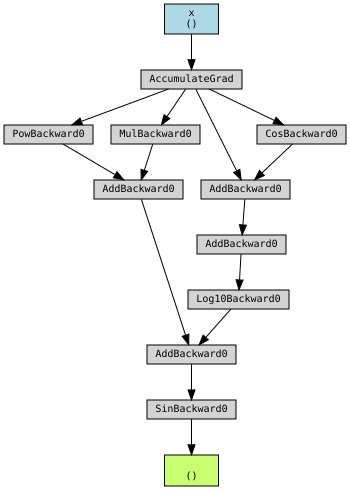

In [11]:

x = torch.tensor(2.0, requires_grad=True)
y = x ** 2 + 3 * x + torch.log10(x + torch.cos(x) + 3)
z = torch.sin(y)

# make_dot(z, params={'x': x}).render("graph", format="png")
make_dot(z, params={'x': x})

In [14]:
x = torch.tensor(2.0, requires_grad=True)
y = x**2 + 3*x
z = torch.sin(y)
y.retain_grad()  # preserve grad for non-leaf node
z.backward()
print("∂z/∂y =", y.grad)
print("∂z/∂x =", x.grad)


∂z/∂y = tensor(-0.8391)
∂z/∂x = tensor(-5.8735)


In [ ]:


# Generator
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(100, 128), nn.ReLU(),
            nn.Linear(128, 784), nn.Tanh()
        )
    def forward(self, z): return self.net(z)

# Discriminator
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784, 128), nn.LeakyReLU(0.2),
            nn.Linear(128, 1), nn.Sigmoid()
        )
    def forward(self, x): return self.net(x)

G, D = Generator(), Discriminator()
opt_G = optim.Adam(G.parameters(), lr=1e-3)
opt_D = optim.Adam(D.parameters(), lr=1e-3)

for step in range(1000):
    # 1. Train D
    real = torch.randn(32, 784)  # fake "real" samples
    z = torch.randn(32, 100)
    fake = G(z).detach()
    loss_D = -(torch.log(D(real)) + torch.log(1 - D(fake))).mean()
    opt_D.zero_grad(); loss_D.backward(); opt_D.step()

    # 2. Train G
    z = torch.randn(32, 100)
    fake = G(z)
    loss_G = -torch.log(D(fake)).mean()
    opt_G.zero_grad(); loss_G.backward(); opt_G.step()
    if step % 100 == 0:
        print(step, loss_D.item(), loss_G.item())


0 1.335421085357666 0.7132004499435425
100 1.0246907472610474 3.96726655960083
200 1.4091310501098633 3.0042362213134766
300 0.8916276097297668 1.0641043186187744
400 1.6893001794815063 0.6108208894729614
500 1.0406242609024048 0.8903874158859253
600 1.1033694744110107 1.3832937479019165
700 0.6471806764602661 1.3672325611114502
800 0.4841150641441345 2.00966477394104
900 0.5842127203941345 1.8366845846176147
